# Predicted r/s ratios

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vice

from multizone.src.yields.utils import adjusted_agb
import paths

plt.style.use(paths.styles / 'notebook.mplstyle')

SFH_TIMESCALE = 15
SFH_RISE = 2
AGB_STUDY = 'cristallo11'
END_TIME = 13.2 # Gyr
SOLAR_CE_S_FRAC = 0.77 # Solar s-process fraction (Arlandini et al. 1999)
SOLAR_AGE = 4.6 # Gyr
ETA_SUN = 0.5 # default mass-loading factor at Solar radius
TAU_STAR = 2 # SFE timescale in Gyr
MIN_DELAY = 0.01 # Minimum delay time for delayed r-process enrichment

OUTPUT_DIR = paths.data / 'onezone' / 'rs_ratios'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DT = 0.01

In [56]:
simtime = np.arange(0, END_TIME+DT, DT)

def sfh(time):
    return (1 - np.exp(-time/SFH_RISE)) * np.exp(-time/SFH_TIMESCALE)

def normalize(func):
    simtime = np.arange(0, END_TIME+DT, DT)
    integral = np.sum(DT * func(simtime))
    f = lambda t: 1/integral * func(t)
    return f

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce cs 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements do not have a well known solar abundance: cs 
For this reason

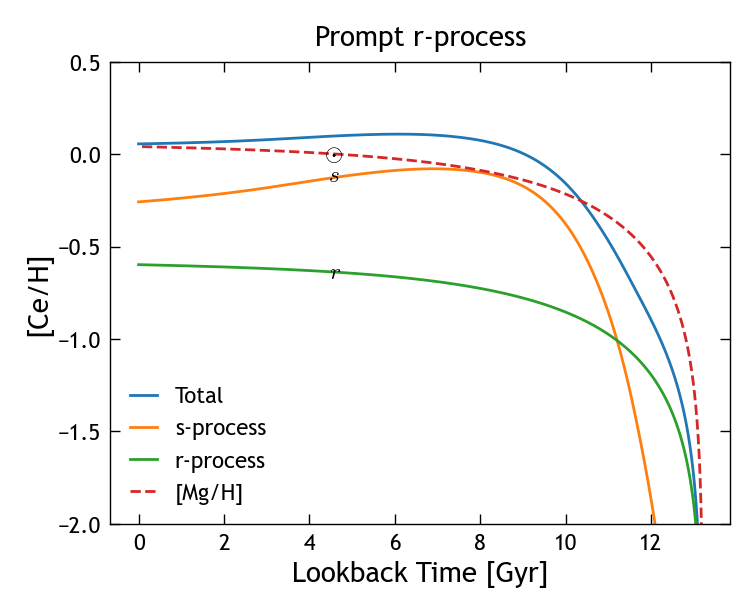

In [57]:
# Yields
from multizone.src.yields import W24 # CCSN and SN Ia
# Arbitrarily scale AGB yield to reproduce Solar abundance at Solar age
vice.yields.agb.settings['ce'] = adjusted_agb('ce', amp=0.7, study=AGB_STUDY)
# Calculate r-process Ce yield (assigned to CCSNe for convenience)
ccsn_ce_yield = vice.yields.ccsne.settings['mg'] * (
    (1 - SOLAR_CE_S_FRAC) * vice.solar_z['ce'] / vice.solar_z['mg']
)
vice.yields.ccsne.settings['ce'] = ccsn_ce_yield
# Assign cs to be the s-process contribution of ce, and cr to be the r-process contribution
vice.solar_z['cs'] = vice.solar_z['ce']
vice.yields.ccsne.settings['cs'] = 0.
vice.yields.sneia.settings['cs'] = 0.
vice.yields.agb.settings['cs'] = vice.yields.agb.settings['ce']
vice.solar_z['cr'] = vice.solar_z['ce']
vice.yields.ccsne.settings['cr'] = ccsn_ce_yield
vice.yields.sneia.settings['cr'] = 0.
vice.yields.agb.settings['cr'] = adjusted_agb('ce', amp=1e-9, study=AGB_STUDY)

# Model 1: prompt r-process only
name = 'promptr'
sz = vice.singlezone(
    name=str(OUTPUT_DIR / name),
    func=normalize(sfh),
    mode='sfr',
    elements=('fe', 'mg', 'ce', 'cs', 'cr'),
    IMF='kroupa',
    eta=ETA_SUN,
    delay=MIN_DELAY,
    RIa='plaw',
    tau_star=TAU_STAR,
    dt=DT,
)
sz.run(simtime, overwrite=True)
hist = vice.history(str(OUTPUT_DIR / name))
# hist = vice.history(str(paths.data / 'onezone/agb/amp1-norproc'))

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(hist['lookback'], hist['[ce/h]'], label='Total')
ax.plot(hist['lookback'], hist['[cs/h]'], label='s-process')
ax.plot(hist['lookback'], hist['[cr/h]'], label='r-process')
ax.plot(hist['lookback'], hist['[mg/h]'], linestyle='--', label='[Mg/H]')
# indicate Solar values
ax.text(
    SOLAR_AGE, 0, r'$\odot$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.text(
    SOLAR_AGE, np.log10(SOLAR_CE_S_FRAC), r'$s$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.text(
    SOLAR_AGE, np.log10(1-SOLAR_CE_S_FRAC), r'$r$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.set_xlabel('Lookback Time [Gyr]')
ax.set_ylabel('[Ce/H]')
ax.set_title('Prompt r-process')
ax.set_ylim((-2, 0.5))
ax.legend()
plt.show()

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce cs 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements do not have a well known solar abundance: cs 
For this reason

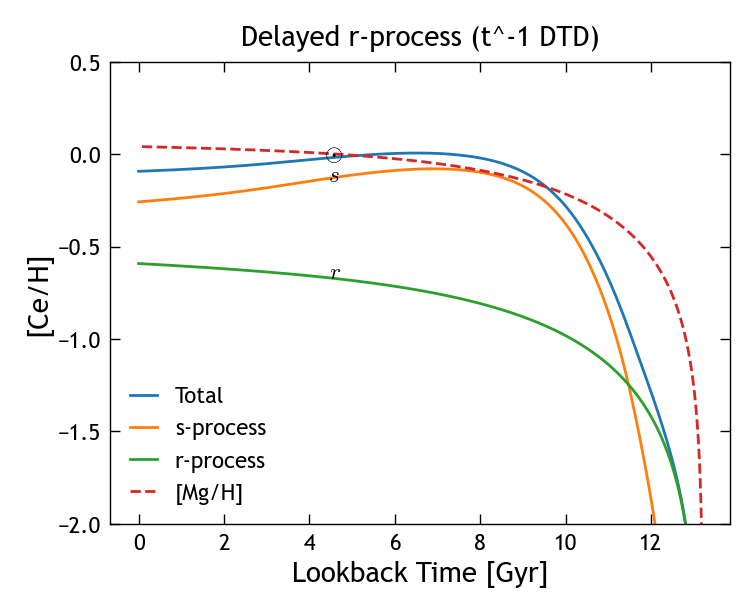

In [58]:
vice.yields.ccsne.settings['ce'] = 0.
vice.yields.sneia.settings['ce'] = ccsn_ce_yield
# Assign cs to be the s-process contribution of ce, and cr to be the r-process contribution
vice.solar_z['cs'] = vice.solar_z['ce']
vice.yields.ccsne.settings['cs'] = 0.
vice.yields.sneia.settings['cs'] = 0.
vice.yields.agb.settings['cs'] = vice.yields.agb.settings['ce']
vice.solar_z['cr'] = vice.solar_z['ce']
vice.yields.ccsne.settings['cr'] = 0.
vice.yields.sneia.settings['cr'] = ccsn_ce_yield
vice.yields.agb.settings['cr'] = adjusted_agb('ce', amp=1e-9, study=AGB_STUDY)

# Model 2: delayed r-process only
name = 'delayedr-plaw'
sz = vice.singlezone(
    name=str(OUTPUT_DIR / name),
    func=normalize(sfh),
    mode='sfr',
    elements=('fe', 'mg', 'ce', 'cs', 'cr'),
    IMF='kroupa',
    eta=ETA_SUN,
    delay=MIN_DELAY,
    RIa='plaw',
    tau_star=TAU_STAR,
    dt=DT,
)
sz.run(simtime, overwrite=True)
hist = vice.history(str(OUTPUT_DIR / name))

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(hist['lookback'], hist['[ce/h]'], label='Total')
ax.plot(hist['lookback'], hist['[cs/h]'], label='s-process')
ax.plot(hist['lookback'], hist['[cr/h]'], label='r-process')
ax.plot(hist['lookback'], hist['[mg/h]'], linestyle='--', label='[Mg/H]')
# indicate Solar values
ax.text(
    SOLAR_AGE, 0, r'$\odot$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.text(
    SOLAR_AGE, np.log10(SOLAR_CE_S_FRAC), r'$s$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.text(
    SOLAR_AGE, np.log10(1-SOLAR_CE_S_FRAC), r'$r$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.set_xlabel('Lookback Time [Gyr]')
ax.set_ylabel('[Ce/H]')
ax.set_title('Delayed r-process (t^-1 DTD)')
ax.set_ylim((-2, 0.5))
ax.legend()
plt.show()

In [59]:
ccsn_ce_yield

9.2432934058959e-10

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce cs 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements do not have a well known solar abundance: cs 
For this reason

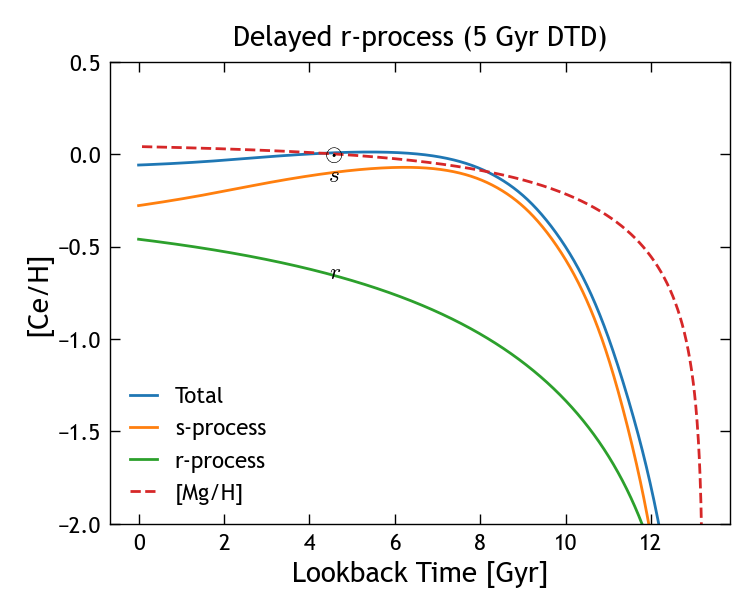

In [60]:
# Arbitrarily scale up delayed r-process yield to match Solar abundance at Solar age
ccsn_ce_yield = 1.2e-9
vice.yields.sneia.settings['ce'] = ccsn_ce_yield
vice.yields.sneia.settings['cr'] = ccsn_ce_yield
# Similarly scale down AGB yield
vice.yields.agb.settings['ce'] = adjusted_agb('ce', study=AGB_STUDY, amp=0.6)
vice.yields.agb.settings['cs'] = vice.yields.agb.settings['ce']

# Model 3: super delayed r-process only
name = 'delayedr-exp5'
sz = vice.singlezone(
    name=str(OUTPUT_DIR / name),
    func=normalize(sfh),
    mode='sfr',
    elements=('fe', 'mg', 'ce', 'cs', 'cr'),
    IMF='kroupa',
    eta=ETA_SUN,
    delay=MIN_DELAY,
    RIa='exp',
    tau_ia=5,
    tau_star=TAU_STAR,
    dt=DT,
)
sz.run(simtime, overwrite=True)
hist = vice.history(str(OUTPUT_DIR / name))

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(hist['lookback'], hist['[ce/h]'], label='Total')
ax.plot(hist['lookback'], hist['[cs/h]'], label='s-process')
ax.plot(hist['lookback'], hist['[cr/h]'], label='r-process')
ax.plot(hist['lookback'], hist['[mg/h]'], linestyle='--', label='[Mg/H]')

# hist = vice.history(str(OUTPUT_DIR / 'promptr'))
# ax.plot(hist['lookback'], hist['[cs/h]'], ls='--', label='Reference s-process')
# indicate Solar values
ax.text(
    SOLAR_AGE, 0, r'$\odot$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.text(
    SOLAR_AGE, np.log10(SOLAR_CE_S_FRAC), r'$s$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.text(
    SOLAR_AGE, np.log10(1-SOLAR_CE_S_FRAC), r'$r$',
    va='center', ha='center', zorder=10, usetex=True
)
ax.set_xlabel('Lookback Time [Gyr]')
ax.set_ylabel('[Ce/H]')
ax.set_title('Delayed r-process (5 Gyr DTD)')
ax.set_ylim((-2, 0.5))
ax.legend()
plt.show()

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_73463/1712033151.py:11: RuntimeWarning: divide by zero encountered in divide
  rs_ratio = rproc / sproc
/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_73463/1712033151.py:11: RuntimeWarning: invalid value encountered in divide
  rs_ratio = rproc / sproc


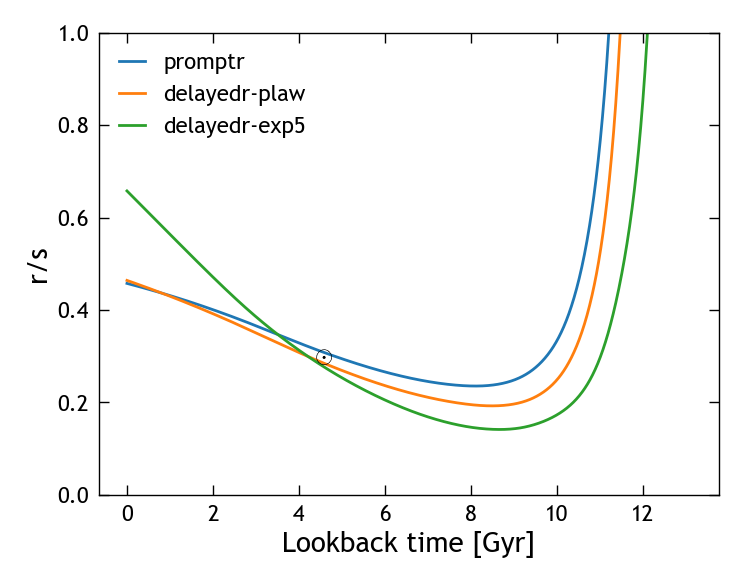

In [63]:
fig, ax = plt.subplots(figsize=(4, 3))

# ax.plot([-1, 14], [1, 1], 'k:')
for name in ['promptr', 'delayedr-plaw', 'delayedr-exp5']:
    hist = vice.history(str(OUTPUT_DIR / name))
    rproc = 10**np.array(hist['[cr/h]'])
    sproc = 10**np.array(hist['[cs/h]'])
    # print(name)
    # print(rproc[:20])
    # print(sproc[:20])
    rs_ratio = rproc / sproc
    ax.plot(hist['lookback'], rs_ratio, label=name)

# indicate Solar ratio
sr_sun = (1 - SOLAR_CE_S_FRAC) / SOLAR_CE_S_FRAC
ax.text(
    SOLAR_AGE, sr_sun, r'$\odot$',
    va='center', ha='center', zorder=10, usetex=True
)

ax.set_xlabel('Lookback time [Gyr]')
ax.set_ylabel('r/s')
ax.set_ylim((0, 1))
# ax.set_ylim((5e-2, 2e1))
# ax.set_yscale('log')
ax.legend()
plt.show()